# Milestone Project II: Bulldozers Sale Price Prediction

## 1. Problem Definition

> Goal: Predict the auction sale price for a piece of heavy equipment to create a "blue book" for bulldozers.

**Note:** An overview of this project can be found in the following link --> https://www.kaggle.com/c/bluebook-for-bulldozers/data

## 2. Data 

The data for this competition is split into three parts:

- **Data.csv** is the training set, which contains data through the end of 2011.
- **Valid.csv** is the validation set, which contains data from January 1, 2012 - April 30, 2012. You make predictions on this set throughout the majority of the competition. Your score on this set is used to create the public leaderboard.
-  **Test.csv**  is the test set, which won't be released until the last week of the competition. It contains data from May 1, 2012 - November 2012. Your score on the test set determines your final rank for the competition.
  
The key fields are in  ***train.csv***:

SalesID: the unique identifier the sale.
MachineID: the unique identifier of a machine.  A machine can be sold multiple times.
saleprice: what the machine sold for at auction.
saledate: the date of the sale.

There are several fields towards the end of the file on the different options a machine can have.  The descriptions all start with "machine configuration" in the data dictionary.  Some product types do not have a particular option, so all the records for that option variable will be null for that product type.  Also, some sources do not provide good option and/or data.

The **Machine_Appendix.csv** file contains the correct year manufactured for a given machine along with the make, model, and product class. There is a machine ID for every machine in all the competition dataset.


## 3. 
The evaluation metric for this competition is the RMSLE (root mean squared log error) between the actual and predicted auction

## 4. Features 

All the information related with the dataset can be found in **Data Dictionary.xlsx** file.

In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [81]:
# Import train and valid data
df = pd.read_csv('bluebook-for-bulldozers/TrainAndValid.csv', low_memory = False)

In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412698 entries, 0 to 412697
Data columns (total 53 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   SalesID                   412698 non-null  int64  
 1   SalePrice                 412698 non-null  float64
 2   MachineID                 412698 non-null  int64  
 3   ModelID                   412698 non-null  int64  
 4   datasource                412698 non-null  int64  
 5   auctioneerID              392562 non-null  float64
 6   YearMade                  412698 non-null  int64  
 7   MachineHoursCurrentMeter  147504 non-null  float64
 8   UsageBand                 73670 non-null   object 
 9   saledate                  412698 non-null  object 
 10  fiModelDesc               412698 non-null  object 
 11  fiBaseModel               412698 non-null  object 
 12  fiSecondaryDesc           271971 non-null  object 
 13  fiModelSeries             58667 non-null   o

In [83]:
# SUM NaN 
df.isna().sum()

SalesID                          0
SalePrice                        0
MachineID                        0
ModelID                          0
datasource                       0
auctioneerID                 20136
YearMade                         0
MachineHoursCurrentMeter    265194
UsageBand                   339028
saledate                         0
fiModelDesc                      0
fiBaseModel                      0
fiSecondaryDesc             140727
fiModelSeries               354031
fiModelDescriptor           337882
ProductSize                 216605
fiProductClassDesc               0
state                            0
ProductGroup                     0
ProductGroupDesc                 0
Drive_System                305611
Enclosure                      334
Forks                       214983
Pad_Type                    331602
Ride_Control                259970
Stick                       331602
Transmission                224691
Turbocharged                331602
Blade_Extension     

In [84]:
display(df)

,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,saledate,...,Undercarriage_Pad_Width,Stick_Length,Thumb,Pattern_Changer,Grouser_Type,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls
0,1139246,66000.0,999089,3157,121,3.0,2004,68.0,Low,11/16/2006 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139248,57000.0,117657,77,121,3.0,1996,4640.0,Low,3/26/2004 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
2,1139249,10000.0,434808,7009,121,3.0,2001,2838.0,High,2/26/2004 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1139251,38500.0,1026470,332,121,3.0,2001,3486.0,High,5/19/2011 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139253,11000.0,1057373,17311,121,3.0,2007,722.0,Medium,7/23/2009 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
412693,6333344,10000.0,1919201,21435,149,2.0,2005,NaN,NaN,3/7/2012 0:00,...,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN,NaN
412694,6333345,10500.0,1882122,21436,149,2.0,2005,NaN,NaN,1/28/2012 0:00,...,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN,NaN
412695,6333347,12500.0,1944213,21435,149,2.0,2005,NaN,NaN,1/28/2012 0:00,...,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN,NaN
412696,6333348,10000.0,1794518,21435,149,2.0,2006,NaN,NaN,3/7/2012 0:00,...,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN,NaN


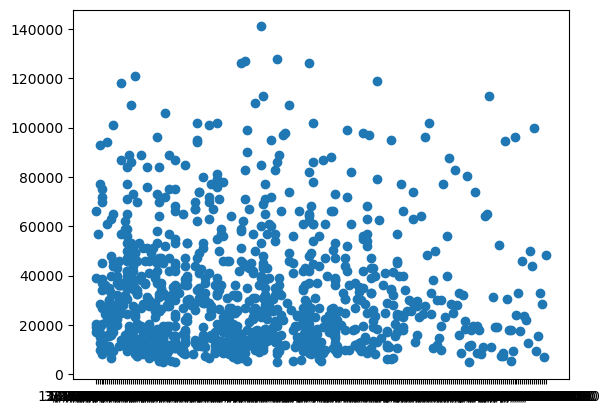

In [85]:
fig, ax = plt.subplots()
ax.scatter(df['saledate'][:1000], df['SalePrice'][:1000])

In [86]:
df.columns

Index(['SalesID', 'SalePrice', 'MachineID', 'ModelID', 'datasource',
       'auctioneerID', 'YearMade', 'MachineHoursCurrentMeter', 'UsageBand',
       'saledate', 'fiModelDesc', 'fiBaseModel', 'fiSecondaryDesc',
       'fiModelSeries', 'fiModelDescriptor', 'ProductSize',
       'fiProductClassDesc', 'state', 'ProductGroup', 'ProductGroupDesc',
       'Drive_System', 'Enclosure', 'Forks', 'Pad_Type', 'Ride_Control',
       'Stick', 'Transmission', 'Turbocharged', 'Blade_Extension',
       'Blade_Width', 'Enclosure_Type', 'Engine_Horsepower', 'Hydraulics',
       'Pushblock', 'Ripper', 'Scarifier', 'Tip_Control', 'Tire_Size',
       'Coupler', 'Coupler_System', 'Grouser_Tracks', 'Hydraulics_Flow',
       'Track_Type', 'Undercarriage_Pad_Width', 'Stick_Length', 'Thumb',
       'Pattern_Changer', 'Grouser_Type', 'Backhoe_Mounting', 'Blade_Type',
       'Travel_Controls', 'Differential_Type', 'Steering_Controls'],
      dtype='object')

<Axes: ylabel='Frequency'>

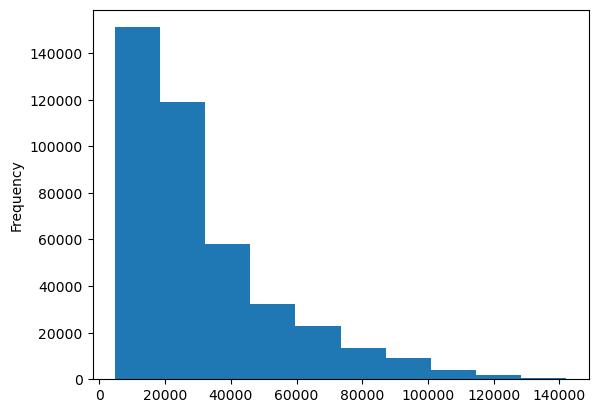

In [87]:
df.SalePrice.plot.hist()

In [88]:
df.saledate[:100]

0     11/16/2006 0:00
1      3/26/2004 0:00
2      2/26/2004 0:00
3      5/19/2011 0:00
4      7/23/2009 0:00
           ...       
95    12/15/2005 0:00
96     1/29/2004 0:00
97     9/18/2008 0:00
98     11/3/2005 0:00
99      6/1/2006 0:00
Name: saledate, Length: 100, dtype: object

## Parsing dates

When working with date-time datasets, 'we want to enrich the date and time component as much as possible'.

We can ask *pandas* to use its `parse_dates` capability when reading the data. That's the why we will import again the dataset, but including the parsing of the data.

In [89]:
df = pd.read_csv('bluebook-for-bulldozers/TrainAndValid.csv', 
                 low_memory = False,
                 parse_dates=['saledate'])

In [90]:
print(df.saledate[:100])

0    2006-11-16
1    2004-03-26
2    2004-02-26
3    2011-05-19
4    2009-07-23
        ...    
95   2005-12-15
96   2004-01-29
97   2008-09-18
98   2005-11-03
99   2006-06-01
Name: saledate, Length: 100, dtype: datetime64[ns]


We can see the saledate has changed its dtype. (before it was object). Now lets re-check our data!

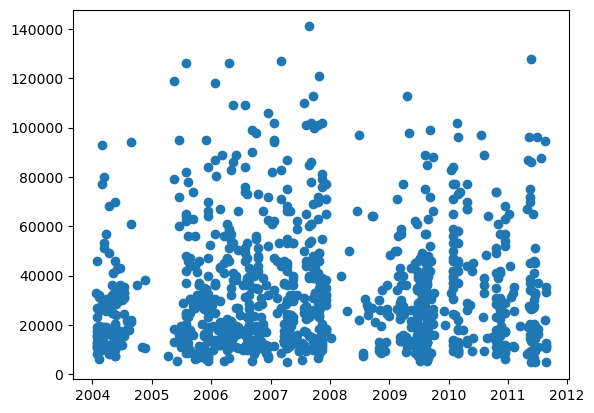

In [91]:
fig, ax = plt.subplots()
ax.scatter(df['saledate'][:1000], df['SalePrice'][:1000])

Now the graph looks so much better!

In [92]:
df.saledate.dtype

dtype('<M8[ns]')

### Sort DataFrame by its saledate

It is a best practice to sort all the data by date. This will permit better understanding and a more linear way to see the progression.

We sort the data by their saledate.

In [93]:
# Sort DataFrame by their date
df.sort_values(by=['saledate'], inplace= True, ascending= True)

In [94]:
# Lets's view the data now
display(df.saledate)

205615   1989-01-17
274835   1989-01-31
141296   1989-01-31
212552   1989-01-31
62755    1989-01-31
            ...    
410879   2012-04-28
412476   2012-04-28
411927   2012-04-28
407124   2012-04-28
409203   2012-04-28
Name: saledate, Length: 412698, dtype: datetime64[ns]

In [95]:
# Make copy of DataFrame. Thus, we have the original version for comparing and other miscellaneous activities. AKA if we fucked it up, we still have the original DataFrame
df_tmp = df.copy()

In [96]:
df_tmp.saledate

205615   1989-01-17
274835   1989-01-31
141296   1989-01-31
212552   1989-01-31
62755    1989-01-31
            ...    
410879   2012-04-28
412476   2012-04-28
411927   2012-04-28
407124   2012-04-28
409203   2012-04-28
Name: saledate, Length: 412698, dtype: datetime64[ns]

In [97]:
df_tmp.head(10).T

,205615,274835,141296,212552,62755,54653,81383,204924,135376,113390
SalesID,1646770,1821514,1505138,1671174,1329056,1301884,1379228,1645390,1493279,1449549
SalePrice,9500.0,14000.0,50000.0,16000.0,22000.0,23500.0,31000.0,11750.0,63000.0,13000.0
MachineID,1126363,1194089,1473654,1327630,1336053,1182999,1082797,1527216,1363756,1289412
ModelID,8434,10150,4139,8591,4089,4123,7620,8202,2759,3356
datasource,132,132,132,132,132,132,132,132,132,132
auctioneerID,18.0,99.0,99.0,99.0,99.0,99.0,99.0,99.0,99.0,99.0
YearMade,1974,1980,1978,1980,1984,1976,1986,1970,1987,1966
MachineHoursCurrentMeter,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UsageBand,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
saledate,1989-01-17 00:00:00,1989-01-31 00:00:00,1989-01-31 00:00:00,1989-01-31 00:00:00,1989-01-31 00:00:00,1989-01-31 00:00:00,1989-01-31 00:00:00,1989-01-31 00:00:00,1989-01-31 00:00:00,1989-01-31 00:00:00


### Enrich of the date and time

Now we proceed with the data enrichment. 

The idea relies in using the DatetimeIndex object to extract useful information about the time of the event (in this case the saledate). For example, we can specify the year, month, day, day of the week, if it's in the beginning/end of the year, in the first/last quarter, etc. 

When we are talking about enrich we are saying that we will add these extra features in the data to maximize the results in our machine learning model
(**Feature Engineering**, link to know more about this https://towardsdatascience.com/what-is-feature-engineering-importance-tools-and-techniques-for-machine-learning-2080b0269f10)

In [98]:
# Add some extra datetime features in the DataFrame
df_tmp['saleYear'] = df_tmp.saledate.dt.year
df_tmp['saleMonth'] = df_tmp.saledate.dt.month
df_tmp['saleDay'] = df_tmp.saledate.dt.day
df_tmp['saleDayOfWeek'] = df_tmp.saledate.dt.dayofweek
df_tmp['saleDayOfYear'] = df_tmp.saledate.dt.dayofyear

In [99]:
# drop saledate column
df_tmp.drop(columns=['saledate'], inplace= True, axis = 1)

# Display our data 
display(df_tmp.head(20).T)

,205615,274835,141296,212552,62755,54653,81383,204924,135376,113390,113394,116419,32138,127610,76171,127000,128130,127626,55455,55454
SalesID,1646770,1821514,1505138,1671174,1329056,1301884,1379228,1645390,1493279,1449549,1449555,1453775,1264985,1475641,1364654,1474844,1476264,1475662,1305337,1305336
SalePrice,9500.0,14000.0,50000.0,16000.0,22000.0,23500.0,31000.0,11750.0,63000.0,13000.0,10500.0,20000.0,20000.0,23500.0,14000.0,11250.0,29000.0,22000.0,17000.0,17000.0
MachineID,1126363,1194089,1473654,1327630,1336053,1182999,1082797,1527216,1363756,1289412,1102310,1514650,1204499,1194367,1270628,1279993,1245504,1242833,1517075,1236263
ModelID,8434,10150,4139,8591,4089,4123,7620,8202,2759,3356,3356,7008,6788,7277,7289,7257,7277,7277,3356,3356
datasource,132,132,132,132,132,132,132,132,132,132,132,132,132,132,132,132,132,132,132,132
auctioneerID,18.0,99.0,99.0,99.0,99.0,99.0,99.0,99.0,99.0,99.0,99.0,99.0,99.0,99.0,99.0,99.0,99.0,99.0,99.0,99.0
YearMade,1974,1980,1978,1980,1984,1976,1986,1970,1987,1966,1966,1974,1984,1973,1968,1979,1978,1973,1972,1972
MachineHoursCurrentMeter,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UsageBand,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fiModelDesc,TD20,A66,D7G,A62,D3B,D6C,IT12,544,D5HII,12F,12F,225,580,950,980,910,950,950,12F,12F


# 5. Modelling

We have done enough EDA. Now let's start with model-driven EDA.

In [100]:
# Import model
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_jobs = -1, # To use all the cores of my computer. We have a  very large number of data
                              random_state= 42) # Equivalent to np.random.seed(42)

Before proceeding with the model fit, we must take care of the missing values and the dtype of the features. 

As we can see below, several features of our dataset are dtype object, unusable for our ML model to fit the data.

In [101]:
df_tmp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 412698 entries, 205615 to 409203
Data columns (total 57 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   SalesID                   412698 non-null  int64  
 1   SalePrice                 412698 non-null  float64
 2   MachineID                 412698 non-null  int64  
 3   ModelID                   412698 non-null  int64  
 4   datasource                412698 non-null  int64  
 5   auctioneerID              392562 non-null  float64
 6   YearMade                  412698 non-null  int64  
 7   MachineHoursCurrentMeter  147504 non-null  float64
 8   UsageBand                 73670 non-null   object 
 9   fiModelDesc               412698 non-null  object 
 10  fiBaseModel               412698 non-null  object 
 11  fiSecondaryDesc           271971 non-null  object 
 12  fiModelSeries             58667 non-null   object 
 13  fiModelDescriptor         74816 non-null   o

With the method `pandas.api.types.is_string_dtype()` we can check wether or not the array corresponds to the string dtype. 

We use a loop to check them.

In [102]:
# Loop for checking the if the feature is string dtype
for label, content in df_tmp.items():
    if pd.api.types.is_string_dtype(content) == True:
        print(label)

fiModelDesc
fiBaseModel
fiProductClassDesc
state
ProductGroup
ProductGroupDesc


In [103]:
display(df_tmp.head().T)

,205615,274835,141296,212552,62755
SalesID,1646770,1821514,1505138,1671174,1329056
SalePrice,9500.0,14000.0,50000.0,16000.0,22000.0
MachineID,1126363,1194089,1473654,1327630,1336053
ModelID,8434,10150,4139,8591,4089
datasource,132,132,132,132,132
auctioneerID,18.0,99.0,99.0,99.0,99.0
YearMade,1974,1980,1978,1980,1984
MachineHoursCurrentMeter,NaN,NaN,NaN,NaN,NaN
UsageBand,NaN,NaN,NaN,NaN,NaN
fiModelDesc,TD20,A66,D7G,A62,D3B


In [104]:
for label, content in df_tmp.items():
    print(f'For feature {label} its dtype is {pd.api.types.infer_dtype(content)}')

For feature SalesID its dtype is integer
For feature SalePrice its dtype is floating
For feature MachineID its dtype is integer
For feature ModelID its dtype is integer
For feature datasource its dtype is integer
For feature auctioneerID its dtype is floating
For feature YearMade its dtype is integer
For feature MachineHoursCurrentMeter its dtype is floating
For feature UsageBand its dtype is string
For feature fiModelDesc its dtype is string
For feature fiBaseModel its dtype is string
For feature fiSecondaryDesc its dtype is string
For feature fiModelSeries its dtype is string
For feature fiModelDescriptor its dtype is string
For feature ProductSize its dtype is string
For feature fiProductClassDesc its dtype is string
For feature state its dtype is string
For feature ProductGroup its dtype is string
For feature ProductGroupDesc its dtype is string
For feature Drive_System its dtype is string
For feature Enclosure its dtype is string
For feature Forks its dtype is string
For feature P

It seems that all the object features are string type, but if any label has at least one missing value (aka NaN), then `pandas.api.types.is_string_type()` method does not recognize it as string type.

So, what I am going to do is to store all the string type in a list, and I will loop over that list in my dataframe to convert the string type into categorical type. 

In [105]:
# Create list of string type labels
string_labels_list = []

# Loop
for label, content in df_tmp.items():
    if pd.api.types.infer_dtype(content) == 'string': 
        string_labels_list.append(label)

# Display list
print(f'String type labels are: {string_labels_list}')

String type labels are: ['UsageBand', 'fiModelDesc', 'fiBaseModel', 'fiSecondaryDesc', 'fiModelSeries', 'fiModelDescriptor', 'ProductSize', 'fiProductClassDesc', 'state', 'ProductGroup', 'ProductGroupDesc', 'Drive_System', 'Enclosure', 'Forks', 'Pad_Type', 'Ride_Control', 'Stick', 'Transmission', 'Turbocharged', 'Blade_Extension', 'Blade_Width', 'Enclosure_Type', 'Engine_Horsepower', 'Hydraulics', 'Pushblock', 'Ripper', 'Scarifier', 'Tip_Control', 'Tire_Size', 'Coupler', 'Coupler_System', 'Grouser_Tracks', 'Hydraulics_Flow', 'Track_Type', 'Undercarriage_Pad_Width', 'Stick_Length', 'Thumb', 'Pattern_Changer', 'Grouser_Type', 'Backhoe_Mounting', 'Blade_Type', 'Travel_Controls', 'Differential_Type', 'Steering_Controls']


To better understand the methods, syntax, etc used refer to: 

`pandas.cat` type --> https://pandas.pydata.org/docs/reference/series.html#accessors
`pandas.api.types.is_string_type()` and `pandas.api.types.infer_dtype()` --> https://pandas.pydata.org/docs/reference/index.html

In [106]:
# Change all string to categorical types in our dataset (or DataFrame)
for label in string_labels_list:
    df_tmp[label] = df_tmp[label].astype("category").cat.as_ordered()

In [107]:
# Check DataFrame info. Now we should see that former string types are now categorical dtype
df_tmp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 412698 entries, 205615 to 409203
Data columns (total 57 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   SalesID                   412698 non-null  int64   
 1   SalePrice                 412698 non-null  float64 
 2   MachineID                 412698 non-null  int64   
 3   ModelID                   412698 non-null  int64   
 4   datasource                412698 non-null  int64   
 5   auctioneerID              392562 non-null  float64 
 6   YearMade                  412698 non-null  int64   
 7   MachineHoursCurrentMeter  147504 non-null  float64 
 8   UsageBand                 73670 non-null   category
 9   fiModelDesc               412698 non-null  category
 10  fiBaseModel               412698 non-null  category
 11  fiSecondaryDesc           271971 non-null  category
 12  fiModelSeries             58667 non-null   category
 13  fiModelDescriptor         748

In [108]:
df_tmp.head().T

,205615,274835,141296,212552,62755
SalesID,1646770,1821514,1505138,1671174,1329056
SalePrice,9500.0,14000.0,50000.0,16000.0,22000.0
MachineID,1126363,1194089,1473654,1327630,1336053
ModelID,8434,10150,4139,8591,4089
datasource,132,132,132,132,132
auctioneerID,18.0,99.0,99.0,99.0,99.0
YearMade,1974,1980,1978,1980,1984
MachineHoursCurrentMeter,NaN,NaN,NaN,NaN,NaN
UsageBand,NaN,NaN,NaN,NaN,NaN
fiModelDesc,TD20,A66,D7G,A62,D3B


In [109]:
# Let's check some categories 
df_tmp.state.cat.categories

Index(['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado',
       'Connecticut', 'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho',
       'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana',
       'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota',
       'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada',
       'New Hampshire', 'New Jersey', 'New Mexico', 'New York',
       'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon',
       'Pennsylvania', 'Puerto Rico', 'Rhode Island', 'South Carolina',
       'South Dakota', 'Tennessee', 'Texas', 'Unspecified', 'Utah', 'Vermont',
       'Virginia', 'Washington', 'Washington DC', 'West Virginia', 'Wisconsin',
       'Wyoming'],
      dtype='object')

In [110]:
print(df_tmp.Ripper.cat.categories, df_tmp.Turbocharged.cat.categories, df_tmp.Hydraulics.cat.categories)

Index(['Multi Shank', 'None or Unspecified', 'Single Shank', 'Yes'], dtype='object') Index(['None or Unspecified', 'Yes'], dtype='object') Index(['2 Valve', '3 Valve', '4 Valve', 'Auxiliary', 'Base + 1 Function',
       'Base + 2 Function', 'Base + 3 Function', 'Base + 4 Function',
       'Base + 5 Function', 'Base + 6 Function', 'None or Unspecified',
       'Standard'],
      dtype='object')


We have turned the string type feautres into categorical (pandas) features. This enable to any ML model to read and interpret the dataset for training and operation. 

Just like the DatatimeIndex (dt in pandas) can give us some informations (e.g. day, year, second, quarter, etc), the categorical features behaves similar. That is we can access to certain information related to the categorical feature.

In [111]:
# You can access the categorical information thorugh pandas.series.cat.<attribute>
df_tmp.state.cat.codes

205615    43
274835     8
141296     8
212552     8
62755      8
          ..
410879     4
412476     4
411927     4
407124     4
409203     4
Length: 412698, dtype: int8

It is a best practice to save the "temporal" DataFrame (df_tmp in this case) to keep (and maybe track) the changes we've done. 

We have changed the feature type from 'string' to 'category' and we have added some new features like Year, Month, etc. extracted from the DataTimeIndex "saledate" Feature.

We still have missing values in our data. Extra data preprocess is required for the proper training of the machine learning model.

In [112]:
# SAVE the f.... DataFrame
# df_tmp.to_csv('bluebook-for-bulldozers/df_tmp.csv', index = False) # It seems it does not save the DataFrame features with category type. 

In [113]:
# Import preprocess data 
# df_tmp = pd.read_csv('bluebook-for-bulldozers/df_tmp.csv',
  #                    low_memory= False)

display(df_tmp)

,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,fiModelDesc,...,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls,saleYear,saleMonth,saleDay,saleDayOfWeek,saleDayOfYear
205615,1646770,9500.0,1126363,8434,132,18.0,1974,NaN,NaN,TD20,...,None or Unspecified,Straight,None or Unspecified,NaN,NaN,1989,1,17,1,17
274835,1821514,14000.0,1194089,10150,132,99.0,1980,NaN,NaN,A66,...,NaN,NaN,NaN,Standard,Conventional,1989,1,31,1,31
141296,1505138,50000.0,1473654,4139,132,99.0,1978,NaN,NaN,D7G,...,None or Unspecified,Straight,None or Unspecified,NaN,NaN,1989,1,31,1,31
212552,1671174,16000.0,1327630,8591,132,99.0,1980,NaN,NaN,A62,...,NaN,NaN,NaN,Standard,Conventional,1989,1,31,1,31
62755,1329056,22000.0,1336053,4089,132,99.0,1984,NaN,NaN,D3B,...,None or Unspecified,PAT,Lever,NaN,NaN,1989,1,31,1,31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
410879,6302984,16000.0,1915521,5266,149,99.0,2001,NaN,NaN,D38E,...,None or Unspecified,PAT,None or Unspecified,NaN,NaN,2012,4,28,5,119
412476,6324811,6000.0,1919104,19330,149,99.0,2004,NaN,NaN,2064,...,NaN,NaN,NaN,NaN,NaN,2012,4,28,5,119
411927,6313029,16000.0,1918416,17244,149,99.0,2004,NaN,NaN,337G,...,NaN,NaN,NaN,NaN,NaN,2012,4,28,5,119
407124,6266251,55000.0,509560,3357,149,99.0,1993,NaN,NaN,12G,...,NaN,NaN,NaN,NaN,NaN,2012,4,28,5,119


## Fill Missing Values

### Filling missing numerical values

In [114]:
# Let's check each features type
for label, content in df_tmp.items():
    print(f'Feature {label} is type {pd.api.types.infer_dtype(content)}.\n')

Feature SalesID is type integer.

Feature SalePrice is type floating.

Feature MachineID is type integer.

Feature ModelID is type integer.

Feature datasource is type integer.

Feature auctioneerID is type floating.

Feature YearMade is type integer.

Feature MachineHoursCurrentMeter is type floating.

Feature UsageBand is type categorical.

Feature fiModelDesc is type categorical.

Feature fiBaseModel is type categorical.

Feature fiSecondaryDesc is type categorical.

Feature fiModelSeries is type categorical.

Feature fiModelDescriptor is type categorical.

Feature ProductSize is type categorical.

Feature fiProductClassDesc is type categorical.

Feature state is type categorical.

Feature ProductGroup is type categorical.

Feature ProductGroupDesc is type categorical.

Feature Drive_System is type categorical.

Feature Enclosure is type categorical.

Feature Forks is type categorical.

Feature Pad_Type is type categorical.

Feature Ride_Control is type categorical.

Feature Stick i

In [115]:
# List of numerical & category features
numerical_features = []
categorical_features = []

for label, content in df_tmp.items():
    if pd.api.types.infer_dtype(content) == 'categorical':
        categorical_features.append(label)
    else:
        numerical_features.append(label)

# Print the lists
print(f'The numerical features are: {numerical_features}. \n\n The categorical features are: {categorical_features}.')

The numerical features are: ['SalesID', 'SalePrice', 'MachineID', 'ModelID', 'datasource', 'auctioneerID', 'YearMade', 'MachineHoursCurrentMeter', 'saleYear', 'saleMonth', 'saleDay', 'saleDayOfWeek', 'saleDayOfYear']. 

 The categorical features are: ['UsageBand', 'fiModelDesc', 'fiBaseModel', 'fiSecondaryDesc', 'fiModelSeries', 'fiModelDescriptor', 'ProductSize', 'fiProductClassDesc', 'state', 'ProductGroup', 'ProductGroupDesc', 'Drive_System', 'Enclosure', 'Forks', 'Pad_Type', 'Ride_Control', 'Stick', 'Transmission', 'Turbocharged', 'Blade_Extension', 'Blade_Width', 'Enclosure_Type', 'Engine_Horsepower', 'Hydraulics', 'Pushblock', 'Ripper', 'Scarifier', 'Tip_Control', 'Tire_Size', 'Coupler', 'Coupler_System', 'Grouser_Tracks', 'Hydraulics_Flow', 'Track_Type', 'Undercarriage_Pad_Width', 'Stick_Length', 'Thumb', 'Pattern_Changer', 'Grouser_Type', 'Backhoe_Mounting', 'Blade_Type', 'Travel_Controls', 'Differential_Type', 'Steering_Controls'].


In [116]:
# Let's see if this function works
for label, content in df_tmp.items():
    if pd.api.types.is_numeric_dtype(content):
        print(label)

SalesID
SalePrice
MachineID
ModelID
datasource
auctioneerID
YearMade
MachineHoursCurrentMeter
saleYear
saleMonth
saleDay
saleDayOfWeek
saleDayOfYear


In [117]:
# Let's see with the is_string blablabla
for label, content in df.items():
    if pd.api.types.is_string_dtype(content):
        print(label)

fiModelDesc
fiBaseModel
fiProductClassDesc
state
ProductGroup
ProductGroupDesc


The first step is to fill the null values in our numerical data. To identify which numerical features have null values we use `pd.isna()`

In [118]:
for label, content in df_tmp.items():
    if pd.api.types.is_numeric_dtype(content):
        if pd.isna(content).sum():
            print(label)

auctioneerID
MachineHoursCurrentMeter


In [119]:
# Fill numeric values with median
for label, content in df_tmp.items():
    if pd.api.types.is_numeric_dtype(content):
        if content.isna().sum():
            df_tmp[label+' is missing'] = pd.isna(content)
            df_tmp[label] = content.fillna(value= content.median())

In [120]:
df_tmp.head(30).T

,205615,274835,141296,212552,62755,54653,81383,204924,135376,113390,...,144032,54438,144952,205752,28927,86971,67034,87602,53101,205784
SalesID,1646770,1821514,1505138,1671174,1329056,1301884,1379228,1645390,1493279,1449549,...,1511962,1301582,1513611,1646995,1259973,1391027,1340383,1391932,1298915,1647221
SalePrice,9500.0,14000.0,50000.0,16000.0,22000.0,23500.0,31000.0,11750.0,63000.0,13000.0,...,17000.0,24000.0,85000.0,10500.0,7700.0,18000.0,110000.0,41000.0,49000.0,15000.0
MachineID,1126363,1194089,1473654,1327630,1336053,1182999,1082797,1527216,1363756,1289412,...,1136546,1199381,1275148,1044876,1150485,1250405,1311130,154142,1338785,1476216
ModelID,8434,10150,4139,8591,4089,4123,7620,8202,2759,3356,...,7464,4123,3371,8443,6788,7008,3406,7008,4124,8443
datasource,132,132,132,132,132,132,132,132,132,132,...,132,132,132,132,132,132,132,132,132,132
auctioneerID,18.0,99.0,99.0,99.0,99.0,99.0,99.0,99.0,99.0,99.0,...,99.0,18.0,99.0,99.0,18.0,99.0,99.0,99.0,99.0,99.0
YearMade,1974,1980,1978,1980,1984,1976,1986,1970,1987,1966,...,1973,1974,1983,1973,1978,1974,1987,1981,1984,1979
MachineHoursCurrentMeter,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
UsageBand,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fiModelDesc,TD20,A66,D7G,A62,D3B,D6C,IT12,544,D5HII,12F,...,D5,D6C,14G,40,580,225,225B,225,D6D,40


In [121]:
# Check numerical values column that do possesses missing values
for label, content in df_tmp.items():
    if pd.api.types.is_numeric_dtype(content):
        if content.isna().sum():
            print(label)

# this should print no value

### Filling and turning categorical values into numbers.

In [122]:
# Check Categrorical features
for label, content in df_tmp.items():
    if isinstance(content, pd.CategoricalDtype): # According to warning this should output the same as the below cell but it doesn't
        print(label)

In [123]:
# Check Categorical features
for label, content in df_tmp.items():
    if pd.api.types.is_categorical_dtype(content):
        print(label)

UsageBand
fiModelDesc
fiBaseModel
fiSecondaryDesc
fiModelSeries
fiModelDescriptor
ProductSize
fiProductClassDesc
state
ProductGroup
ProductGroupDesc
Drive_System
Enclosure
Forks
Pad_Type
Ride_Control
Stick
Transmission
Turbocharged
Blade_Extension
Blade_Width
Enclosure_Type
Engine_Horsepower
Hydraulics
Pushblock
Ripper
Scarifier
Tip_Control
Tire_Size
Coupler
Coupler_System
Grouser_Tracks
Hydraulics_Flow
Track_Type
Undercarriage_Pad_Width
Stick_Length
Thumb
Pattern_Changer
Grouser_Type
Backhoe_Mounting
Blade_Type
Travel_Controls
Differential_Type
Steering_Controls


C:\Users\andre\AppData\Local\Temp\ipykernel_11848\3345151540.py:3: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(content):


Again, we want to store the missing values in *label is missing* and transform the categorical values (string, words, whatever), into numbers. Why? Because computers LOVE number. 

In [124]:
# Convert categories into numbers, and store which values where missing in a new label
for label, content in df_tmp.items():
    if pd.api.types.is_numeric_dtype(content) is not True:
        df_tmp[label+' is missing'] = pd.isna(content)
        df_tmp[label] = pd.Categorical(content).codes + 1

**Why do we add one to the label?** Because the pandas Categorical `codes` attribute convert missing values into -1. 

It is convenient because we can immediately identify missing values (=0) and we don't have negatives values (I still don't know the reason why we want to avoid this. Maybe scikit-learn ML models cannot work with negative categorical features. The -1 gives the user several options on how to proceed)

**Check your current DataFrame!**

In [125]:
print(df_tmp.info(),
      df_tmp.head().T)

<class 'pandas.core.frame.DataFrame'>
Index: 412698 entries, 205615 to 409203
Columns: 103 entries, SalesID to Steering_Controls is missing
dtypes: bool(46), float64(3), int16(4), int32(5), int64(5), int8(40)
memory usage: 73.2 MB
None                                205615   274835   141296   212552   62755 
SalesID                       1646770  1821514  1505138  1671174  1329056
SalePrice                      9500.0  14000.0  50000.0  16000.0  22000.0
MachineID                     1126363  1194089  1473654  1327630  1336053
ModelID                          8434    10150     4139     8591     4089
datasource                        132      132      132      132      132
...                               ...      ...      ...      ...      ...
Backhoe_Mounting is missing     False     True    False     True    False
Blade_Type is missing           False     True    False     True    False
Travel_Controls is missing      False     True    False     True    False
Differential_Type is mis

In [126]:
df_tmp.isna().sum()[-50:-1]

saleMonth                              0
saleDay                                0
saleDayOfWeek                          0
saleDayOfYear                          0
auctioneerID is missing                0
MachineHoursCurrentMeter is missing    0
UsageBand is missing                   0
fiModelDesc is missing                 0
fiBaseModel is missing                 0
fiSecondaryDesc is missing             0
fiModelSeries is missing               0
fiModelDescriptor is missing           0
ProductSize is missing                 0
fiProductClassDesc is missing          0
state is missing                       0
ProductGroup is missing                0
ProductGroupDesc is missing            0
Drive_System is missing                0
Enclosure is missing                   0
Forks is missing                       0
Pad_Type is missing                    0
Ride_Control is missing                0
Stick is missing                       0
Transmission is missing                0
Turbocharged is 

Now that all the data is numeric and there's no missing values, the machine learning model is ready to cook!

When working with heap amount of data, it is also important to mind the time needed for the fitting, tuning, etc

In [127]:
%%time 

# Create model
model = RandomForestRegressor(n_jobs= -1,
                              random_state=42)

# Fit model
model.fit(df_tmp.drop(labels='SalePrice', axis = 1), df_tmp['SalePrice'])

CPU times: total: 37min 7s
Wall time: 5min 18s


RandomForestRegressor(n_jobs=-1, random_state=42)

In [128]:
model.score(df_tmp.drop(labels='SalePrice', axis = 1), df_tmp['SalePrice'])

0.9875468079970562

There is no sense in permorfing the above operation. I did it because I wanted to check if the fitting was performed.

## Splitting Validation and Training Set.

It is noteworthy to mention that our training data years reach until the end of 2011. The validation set starts from 2012 (from Jan to May I think). Next, we will take charge of this. 

**Note:** I realized that we have the date data in our feature matrix. We would like to predict the future prices using past data, but then, the question I ask myself is, Can I use the date data as a variable in my ML model? What would happen if my ML model place a lot of weight in these variables? If the year is treated like a categorical variable, then, how my machine would identify the new category (year 2012)? In our case is a numeric value. Certainly, the year can play a role in the final price (e.g. a bulldozer price in 1989 cannot be the selled at the same price as 2011).

In [129]:
df_tmp.saleYear.value_counts()

saleYear
2009    43849
2008    39767
2011    35197
2010    33390
2007    32208
2006    21685
2005    20463
2004    19879
2001    17594
2000    17415
2002    17246
2003    15254
1998    13046
1999    12793
2012    11573
1997     9785
1996     8829
1995     8530
1994     7929
1993     6303
1992     5519
1991     5109
1989     4806
1990     4529
Name: count, dtype: int64

In [130]:
# Split data into train and vaid 
df_train = df_tmp[df_tmp['saleYear'] != 2012]
df_val = df_tmp[ df_tmp['saleYear'] == 2012]

df_train, df_val

(        SalesID  SalePrice  MachineID  ModelID  datasource  auctioneerID  \
 205615  1646770     9500.0    1126363     8434         132          18.0   
 274835  1821514    14000.0    1194089    10150         132          99.0   
 141296  1505138    50000.0    1473654     4139         132          99.0   
 212552  1671174    16000.0    1327630     8591         132          99.0   
 62755   1329056    22000.0    1336053     4089         132          99.0   
 ...         ...        ...        ...      ...         ...           ...   
 393098  6260687    29000.0    1074871     4331         149           2.0   
 400217  6312170    11000.0    1812622     9580         149           2.0   
 400302  6312727    11000.0    1811599     9580         149           2.0   
 400393  6315051    18000.0    1858173    17432         149           2.0   
 393123  6260878    13500.0    1799594     4102         149           2.0   
 
         YearMade  MachineHoursCurrentMeter  UsageBand  fiModelDesc  ...  

In [131]:
# Split into feature matrix train and val and target variable train and val
X_train, y_train = df_train.drop(columns=['SalePrice']), df_train.SalePrice
X_val, y_val = df_val.drop(columns=['SalePrice']), df_val.SalePrice

In [132]:
X_train.shape, y_train.shape, X_val.shape, y_val.shape

((401125, 102), (401125,), (11573, 102), (11573,))

### Building our own evaluation metric

Remember that the evaluation metric for this problem is the RMSLE (Root Mean Squared Logarithmic Error)

In [133]:
# import evaluation metrics
from sklearn.metrics import mean_squared_log_error, mean_absolute_error, r2_score

def rmsle(y_true, y_preds):
    '''
    It calculates the Root Mean Squared Logarithmic Error between the true and predicted values
    '''
    return np.sqrt(mean_squared_log_error(y_true, y_preds))

def show_scores(model):
    '''
    
    '''
    train_preds = model.predict(X_train)
    val_preds = model.predict(X_val)
    scores = {'Training MAE': mean_absolute_error(y_train, train_preds),
              'Validation MAE': mean_absolute_error(y_val, val_preds), 
              'Training RMSLE': rmsle(y_train, train_preds),
              'Validation RMSLE': rmsle(y_val, val_preds), 
              'Training R^2': r2_score(y_train, train_preds), 
              'Validation R^2': r2_score(y_val, val_preds)}
    return scores

Now we are ready to start experimenting with our ML model. But have in mind one cannot perform dozens on trials. In this case, the first model took a couple of minutes to fit. 

We have several options:
- To use some part of the data. For example `X_train[:10000]`, etc.
- To limit the usage of samples and varaibles in the model.

In [134]:
# create model
model = RandomForestRegressor(n_jobs=-1,
                              max_samples= 10000, 
                              random_state= 42)

In [135]:
%%time 

# fit model 
model.fit(X_train, y_train)

CPU times: total: 1min 40s
Wall time: 15.9 s


RandomForestRegressor(max_samples=10000, n_jobs=-1, random_state=42)

In [136]:
show_scores(model)

{'Training MAE': 5561.2988092240585,
 'Validation MAE': 7177.26365505919,
 'Training RMSLE': 0.257745378256977,
 'Validation RMSLE': 0.29362638671089003,
 'Training R^2': 0.8606658995199189,
 'Validation R^2': 0.8320374995090507}

## RandomizedSearchCV

In [137]:
%%time
from sklearn.model_selection import RandomizedSearchCV

# Estimator
estimator = RandomForestRegressor(n_jobs = -1, 
                                  random_state= 42)

# Grid for the randomized search (hyperparameter tuning)
rf_grid = {'n_estimators': np.arange(10,100,10), 
           'max_depth': [None, 3, 5, 10],
           'min_samples_split': np.arange(2,20,2), 
           'min_samples_leaf': np.arange(1,20,2),
           'max_features': [0.5, 1, 'sqrt', 'log2'],
           'max_samples': [10000]}

# RandomSearchCV
rs_model = RandomizedSearchCV(estimator= estimator, 
                              param_distributions= rf_grid, 
                              n_iter = 100, # 10000
                              cv = 5,
                              verbose = 1)

# Start the random search in the defined grid! 
rs_model.fit(X_train, y_train)

Fitting 5 folds for each of 10000 candidates, totalling 50000 fits
CPU times: total: 2d 3h 59min 50s
Wall time: 14h 55min 46s


RandomizedSearchCV(cv=5,
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_iter=10000,
                   param_distributions={'max_depth': [None, 3, 5, 10],
                                        'max_features': [0.5, 1, 'sqrt',
                                                         'log2'],
                                        'max_samples': [10000],
                                        'min_samples_leaf': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19]),
                                        'min_samples_split': array([ 2,  4,  6,  8, 10, 12, 14, 16, 18]),
                                        'n_estimators': array([10, 20, 30, 40, 50, 60, 70, 80, 90])},
                   verbose=1)

In [138]:
show_scores(rs_model)

{'Training MAE': 5721.061227879921,
 'Validation MAE': 7178.455448985666,
 'Training RMSLE': 0.2636729016313718,
 'Validation RMSLE': 0.2952479820480587,
 'Training R^2': 0.8549130190999683,
 'Validation R^2': 0.8361414909389748}

In [142]:
print(rs_model.best_score_,'\n\n',rs_model.best_params_)

0.7506260896429022 
 {'n_estimators': 90, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_samples': 10000, 'max_features': 0.5, 'max_depth': None}


### Train a model with the best hyperparamers

Once I finish the milestone project, I will increase the number of iterations of our model so that with have (probabilistitc speaking) to find the best hyperparameters of our ML model (estimator). 

After this, it is a good idea to fit our machine learning model with all the data (i.e. there's no need to use `max_samples = 10000`).

### This is the model of ZTM after their long run with RandomizedSearchCV

In [144]:
%%time

# Most ideal hyperparameters
ideal_model = RandomForestRegressor(n_estimators=90,
                                    min_samples_leaf=1,
                                    min_samples_split=2,
                                    max_features= 0.5,
                                    n_jobs=-1, 
                                    max_samples= None,
                                    random_state= 28)

# fit the ideal model
ideal_model.fit(X_train, y_train)

CPU times: total: 14min 13s
Wall time: 1min 59s


RandomForestRegressor(max_features=0.5, n_estimators=90, n_jobs=-1,
                      random_state=28)

In [145]:
show_scores(ideal_model), show_scores(rs_model)

({'Training MAE': 1564.935889172812,
  'Validation MAE': 5903.69131919442,
  'Training RMSLE': 0.08333795686354852,
  'Validation RMSLE': 0.2450119479732077,
  'Training R^2': 0.9880028450007714,
  'Validation R^2': 0.8835402784052343},
 {'Training MAE': 5721.061227879921,
  'Validation MAE': 7178.455448985666,
  'Training RMSLE': 0.2636729016313718,
  'Validation RMSLE': 0.2952479820480587,
  'Training R^2': 0.8549130190999683,
  'Validation R^2': 0.8361414909389748})

The Kaggle website request a pdf with a very specific submission format. The submission format is:
- Have a header: "SalesID,SalePrice"
- Contain two columns
  - **SalesID**: SalesID for the validation set in sorted order

  - **SalePrice**: Your predicted price of the sale
 
## Import Test data

The test data must undergo the same (pre) processing and transformation that our train and validation data.

In [146]:
# Import test data
df_test = pd.read_csv('bluebook-for-bulldozers\Test.csv',
                      parse_dates= ["saledate"],
                      low_memory=False)

# Check some values and info 
print(df_test.info(), df_test.head().T, df_test.shape, df_test.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12457 entries, 0 to 12456
Data columns (total 52 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   SalesID                   12457 non-null  int64         
 1   MachineID                 12457 non-null  int64         
 2   ModelID                   12457 non-null  int64         
 3   datasource                12457 non-null  int64         
 4   auctioneerID              12457 non-null  int64         
 5   YearMade                  12457 non-null  int64         
 6   MachineHoursCurrentMeter  2129 non-null   float64       
 7   UsageBand                 1834 non-null   object        
 8   saledate                  12457 non-null  datetime64[ns]
 9   fiModelDesc               12457 non-null  object        
 10  fiBaseModel               12457 non-null  object        
 11  fiSecondaryDesc           8482 non-null   object        
 12  fiModelSeries     

In [147]:
# Create function for data preprocess
def preprocess_data(df):
    '''
    The function perform all the transformations to the dataframe for the bulldozers sale price prediction. 

    In a nutshell it performs 3 transformations:
    1. Add year, day, etc from the DateTimeIndex "saledate"
    2. fill missing values in categorical features
    3. fill missing values in numerical features
    '''

    # Add extra datetime features in the DataFrame
    df['saleYear'] = df.saledate.dt.year
    df['saleMonth'] = df.saledate.dt.month
    df['saleDay'] = df.saledate.dt.day
    df['saleDayOfWeek'] = df.saledate.dt.dayofweek
    df['saleDayOfYear'] = df.saledate.dt.dayofyear

    df.drop(columns=['saledate'], inplace= True, axis = 1)

    # Transform string data into categorical data and fill missing values
    for label in string_labels_list:
        df[label] = df[label].astype("category").cat.as_ordered()

    # I have to add it here in order to respect the order of the columns to be able to use my ML model's predict method 
    df['auctioneerID is missing'] = False
    
    # Fill missing numerical values
    for label, content in df.items():
        if pd.api.types.is_numeric_dtype(content):
            if content.isna().sum():
                df[label+' is missing'] = pd.isna(content)
                df[label] = content.fillna(value= content.median())

    # Categorical features 
    for label, content in df.items():
        if pd.api.types.is_numeric_dtype(content) is not True:
            df[label+' is missing'] = pd.isna(content)
            df[label] = pd.Categorical(content).codes + 1

    return df

In [148]:
df_test = preprocess_data(df_test)

print(df_test)

       SalesID  MachineID  ModelID  datasource  auctioneerID  YearMade  \
0      1227829    1006309     3168         121             3      1999   
1      1227844    1022817     7271         121             3      1000   
2      1227847    1031560    22805         121             3      2004   
3      1227848      56204     1269         121             3      2006   
4      1227863    1053887    22312         121             3      2005   
...        ...        ...      ...         ...           ...       ...   
12452  6643171    2558317    21450         149             2      2008   
12453  6643173    2558332    21434         149             2      2005   
12454  6643184    2558342    21437         149             2      1000   
12455  6643186    2558343    21437         149             2      2006   
12456  6643196    2558346    21446         149             2      2008   

       MachineHoursCurrentMeter  UsageBand  fiModelDesc  fiBaseModel  ...  \
0                        3688.0   

**IMPORTANT**: The number of columns in `X_train` an `df_test` are different because there is no missing value in `auctioneerID` for the test data. 

Therefore, we must manually introduce the extra column of `auctioneerID is missing` full of `False` values. 

In [149]:
# Now it's the null set because I hhave included the ``auctioneer is missing`` in the function preprocess_data
set(X_train.columns) - set(df_test.columns)

set()

In [150]:
# Create column full of missing values
# df_test['auctioneerID is missing'] = False

In [151]:
df_test['auctioneerID is missing']

0        False
1        False
2        False
3        False
4        False
         ...  
12452    False
12453    False
12454    False
12455    False
12456    False
Name: auctioneerID is missing, Length: 12457, dtype: bool

In [152]:
test_preds = ideal_model.predict(df_test)

print(test_preds)

[17527.77777778 17345.         50833.33333333 ... 12198.33333333
 17867.22222222 28472.22222222]


Data predictions must be stored in a specific format (as pointed out in Kaggle website, in submission format)

In [153]:
# Create DataFrame to save values
bulldozers_preds = pd.DataFrame()

# create SalesID column
bulldozers_preds['SalesID'] = df_test.SalesID

# Create SalePrice column
bulldozers_preds['SalePrice'] = test_preds

print(bulldozers_preds)

       SalesID     SalePrice
0      1227829  17527.777778
1      1227844  17345.000000
2      1227847  50833.333333
3      1227848  69772.222222
4      1227863  53365.555556
...        ...           ...
12452  6643171  44005.555556
12453  6643173  12241.666667
12454  6643184  12198.333333
12455  6643186  17867.222222
12456  6643196  28472.222222

[12457 rows x 2 columns]


Now the last step is to sort our data randomly, as requested by the competition rules

In [154]:
# Sort values randomly
bulldozers_preds = bulldozers_preds.sample(frac=1).reset_index()

In [155]:
display(bulldozers_preds)

,index,SalesID,SalePrice
0,4708,6277896,37461.111111
1,9601,6468596,23038.888889
2,11354,6632138,23750.000000
3,5381,6285062,62307.222222
4,3608,6265726,19847.222222
...,...,...,...
12452,1074,4253821,21085.555556
12453,2200,4940354,26416.666667
12454,8604,6441921,27917.777778
12455,3167,6261042,17891.666667


In [156]:
# Save file
bulldozers_preds.to_csv('bluebook-for-bulldozers/Prediction.csv', index=False)

### Feature Importance

Having finished with the prediction, we would like to answer the question 
> Which features are the most influent when speaking about predicting the Sale Price?

Calculation of feature importance is performed in the next cells. The values are extracted from `pd.RandomForestRegressor().feature_importance_` attribute. (https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html)

In [157]:
ideal_model.feature_importances_

array([3.78805774e-02, 2.39186831e-02, 4.41210445e-02, 2.07588680e-03,
       4.98897459e-03, 1.96296568e-01, 3.88766265e-03, 1.40168481e-03,
       3.78983666e-02, 4.43633009e-02, 5.99043900e-02, 4.97619733e-03,
       2.00213185e-02, 1.40057298e-01, 4.48017913e-02, 9.08988148e-03,
       1.97990793e-03, 2.74662905e-03, 3.80105763e-03, 6.59361780e-02,
       5.41779512e-04, 1.46051505e-04, 9.94867507e-04, 1.86865126e-04,
       1.15635432e-03, 4.54163449e-05, 1.74053777e-03, 3.26764299e-03,
       2.10754683e-03, 3.13184500e-04, 3.97978731e-03, 3.12207389e-03,
       4.42641472e-03, 1.21651802e-03, 3.01587780e-03, 1.06954815e-02,
       1.11882946e-03, 1.02676078e-02, 2.03058116e-03, 1.42354372e-03,
       1.28712204e-03, 1.32134297e-03, 1.49392880e-03, 8.65650794e-04,
       4.69416739e-04, 5.40785808e-04, 5.08291693e-04, 2.62169403e-03,
       9.84127462e-04, 3.10776860e-04, 3.19033745e-04, 7.21068371e-02,
       6.08526660e-03, 9.51634344e-03, 5.04404751e-03, 1.36151209e-02,
      

In [158]:
# create function for plot!
def plot_features(columns, importance, n =20 ): 
    df = (pd.DataFrame({'features': columns, 
                        'feature importance': importance})
         .sort_values(by= 'feature importance', ascending=False)
         .reset_index(drop=True))

    # Plot the Data Frame
    fig, ax = plt.subplots()
    ax.barh(y = df['features'][:n], width = df['feature importance'][:20])
    ax.set_ylabel('Features')
    ax.set_xlabel('Feature importance')
    ax.invert_yaxis()

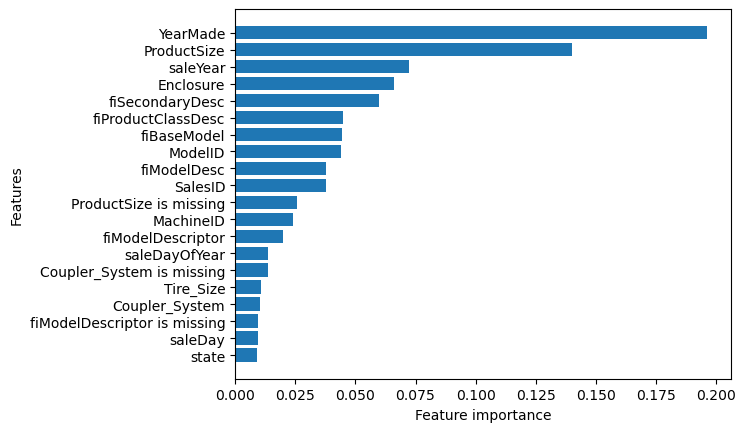

In [159]:
# Columns for plot
columns = X_train.columns

# Feature Importance
importance = ideal_model.feature_importances_

# Horizontal bar plot for feature importance
plot_features(columns, importance)

Let's have a look into the "most important features".

In [160]:
df['YearMade']

205615    1974
274835    1980
141296    1978
212552    1980
62755     1984
          ... 
410879    2001
412476    2004
411927    2004
407124    1993
409203    1000
Name: YearMade, Length: 412698, dtype: int64

In [161]:
df['ProductSize'].value_counts()

ProductSize
Medium            64342
Large / Medium    51297
Small             27057
Mini              25721
Large             21396
Compact            6280
Name: count, dtype: int64

In [162]:
df['fiSecondaryDesc'].value_counts()

fiSecondaryDesc
C         44431
B         40165
G         37915
H         24729
E         21532
          ...  
BLGPPS        1
MSR           1
LC7A          1
CL            1
BH            1
Name: count, Length: 177, dtype: int64

In [163]:
df['Enclosure'].value_counts()

Enclosure
OROPS                  177971
EROPS                  141769
EROPS w AC              92601
EROPS AC                   18
NO ROPS                     3
None or Unspecified         2
Name: count, dtype: int64

**Question to finish**: Why might knowing the feature importances of a trained machine learning model bne helpful?

**Final Challenge**: What other machine learning models could you try on our dataset?